<a href="https://colab.research.google.com/github/Feliz-ua/goit-np-hw-06/blob/main/hw_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/ESC-50-master'
AUDIO_DIR = os.path.join(DATA_DIR, 'audio')
META_FILE = os.path.join(DATA_DIR, 'meta', 'esc50.csv')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 1.Вибірка звуків із мітками 'dog' та 'chirping_birds'.
# Завантажуємо метадані
meta_data = pd.read_csv(META_FILE)

# Вибираємо лише звуки собак та співу птахів
target_categories = ['dog', 'chirping_birds']
filtered_data = meta_data[meta_data['category'].isin(target_categories)]

print(f"Кількість обраних аудіофайлів: {len(filtered_data)}")

Кількість обраних аудіофайлів: 80


Прослуховування: Собака (Гавкіт)


Прослуховування: Спів пташок


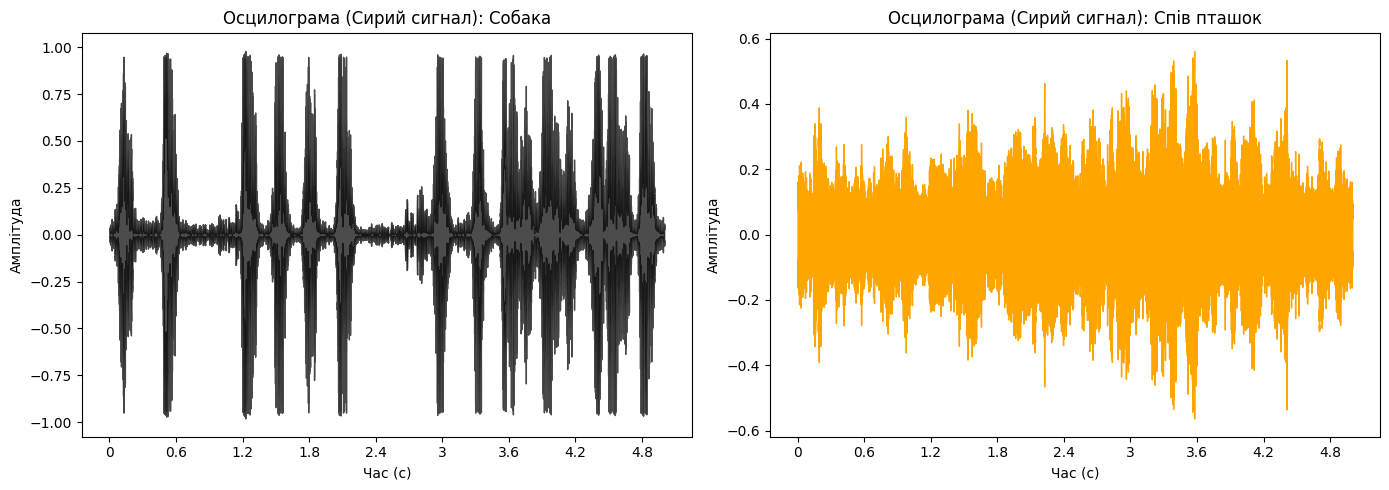

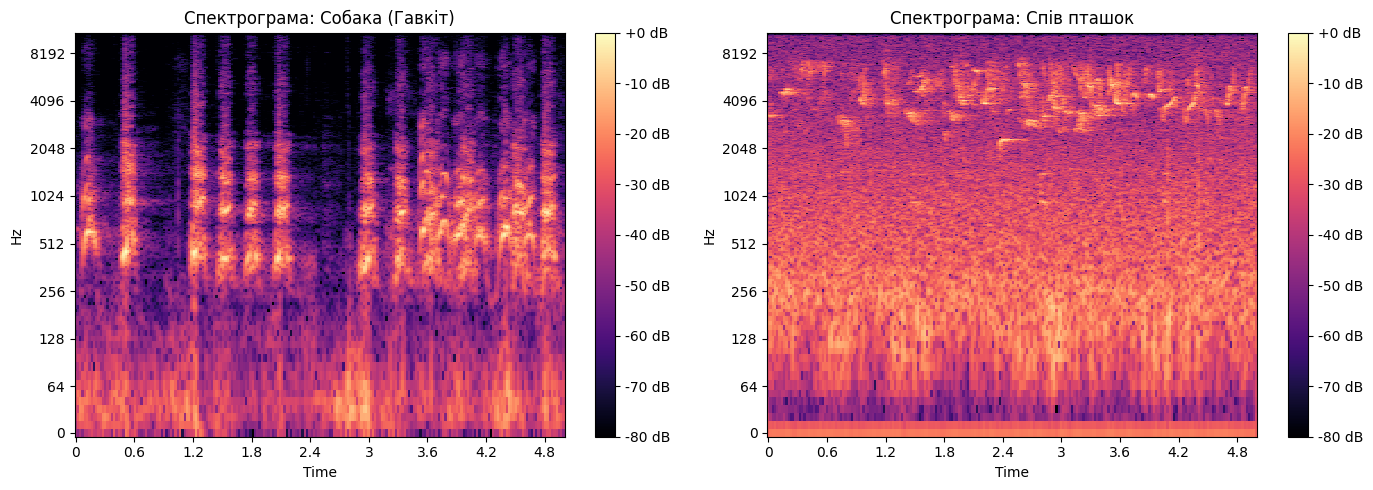

In [9]:
# Порівняння спектограм
# Знаходимо по одному файлу кожної категорії для прикладу
dog_sample_file = filtered_data[filtered_data['category'] == 'dog'].iloc[11]['filename']
bird_sample_file = filtered_data[filtered_data['category'] == 'chirping_birds'].iloc[16]['filename']

dog_path = os.path.join(AUDIO_DIR, dog_sample_file)
bird_path = os.path.join(AUDIO_DIR, bird_sample_file)

print("Прослуховування: Собака (Гавкіт)")
display(ipd.Audio(dog_path))

print("Прослуховування: Спів пташок")
display(ipd.Audio(bird_path))

# Додаємо візуалізацію осцилограм (амплітуда від часу)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

y_dog, sr = librosa.load(dog_path)
y_bird, sr = librosa.load(bird_path)

# Графік для собаки
librosa.display.waveshow(y_dog, sr=sr, ax=ax[0], color='black', alpha=0.7)
ax[0].set_title('Осцилограма (Сирий сигнал): Собака')
ax[0].set_xlabel('Час (с)')
ax[0].set_ylabel('Амплітуда')

# Графік для пташки
librosa.display.waveshow(y_bird, sr=sr, ax=ax[1], color='orange')
ax[1].set_title('Осцилограма (Сирий сигнал): Спів пташок')
ax[1].set_xlabel('Час (с)')
ax[1].set_ylabel('Амплітуда')

plt.tight_layout()
plt.show()

# Генеруємо спектрограми

D_dog = librosa.amplitude_to_db(np.abs(librosa.stft(y_dog)), ref=np.max)
D_bird = librosa.amplitude_to_db(np.abs(librosa.stft(y_bird)), ref=np.max)

# Малюємо поруч дві спектрограми
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

img1 = librosa.display.specshow(D_dog, sr=sr, x_axis='time', y_axis='log', ax=ax[0], cmap='magma')
ax[0].set_title('Спектрограма: Собака (Гавкіт)')
fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")

img2 = librosa.display.specshow(D_bird, sr=sr, x_axis='time', y_axis='log', ax=ax[1], cmap='magma')
ax[1].set_title('Спектрограма: Спів пташок')
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [11]:
# 2.Генерація матриці спектрограми
def get_spectrogram(audio_path, sr=22050):
    y, sr = librosa.load(audio_path, sr=sr)
    # Короткочасне перетворення Фур'є (STFT)
    stft = librosa.stft(y)
    # Переводимо в амплітудну (або логарифмічну) шкалу
    spectrogram = np.abs(stft)
    return spectrogram

In [12]:
# 3. Використання функції pooling для узагальнення та зменшення розміру спектрограми.
def pooling(matrix, pool_size=(4, 4)):
    m, n = matrix.shape
    matrix = matrix[:m - m % pool_size[0], :n - n % pool_size[1]]
    pooled = matrix.reshape(matrix.shape[0] // pool_size[0], pool_size[0],
                            matrix.shape[1] // pool_size[1], pool_size[1])
    return pooled.max(axis=(1, 3))

In [19]:
# 4.Використання методу flatten() для перетворення матриці спектрограми у вектор для подальшого спектрального аналізу.
features = []
labels = []
true_label_mapping = {'dog': 0, 'chirping_birds': 1}

print("Обробка аудіофайлів...")
for index, row in filtered_data.iterrows():
    file_path = os.path.join(AUDIO_DIR, row['filename'])

    spec = get_spectrogram(file_path)

    reduced_spec = pooling(spec, pool_size=(16, 16))

    #Перетворюємо матрицю у вектор за допомогою flatten()
    vector = reduced_spec.flatten()

    features.append(vector)
    labels.append(true_label_mapping[row['category']])

# Перетворюємо у numpy-масиви
X = np.array(features)
y_true = np.array(labels)

print(f"Розмірність матриці ознак після flatten: {X.shape}")

Обробка аудіофайлів...
Розмірність матриці ознак після flatten: (80, 832)


Виконання спектральної кластеризації...


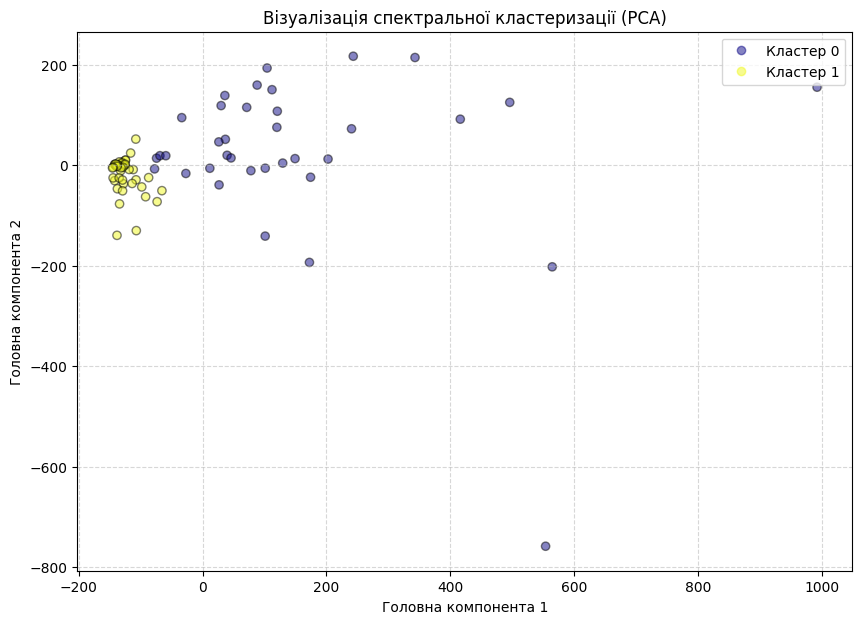

In [20]:
# 5. Використання функції SpectralClustering бібліотеки sklearn для кластеризації отриманих даних
print("Виконання спектральної кластеризації...")
# Використовуємо 2 кластери, оскільки у нас 2 категорії
clustering = SpectralClustering(n_clusters=2, assign_labels='kmeans', random_state=42, affinity='nearest_neighbors')
y_pred = clustering.fit_predict(X)

# Зменшуємо розмірність до 2 за допомогою PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

# Будуємо графік розсіювання (scatter plot)
# Колір точок (c) залежить від того, до якого кластера їх відніс алгоритм (y_pred)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='plasma', alpha=0.5, edgecolors='k')

plt.title('Візуалізація спектральної кластеризації (PCA)')
plt.xlabel('Головна компонента 1')
plt.ylabel('Головна компонента 2')

# Додаємо легенду
plt.legend(handles=scatter.legend_elements()[0], labels=['Кластер 0', 'Кластер 1'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Матриця помилок (Confusion Matrix):
[[34  6]
 [ 2 38]]


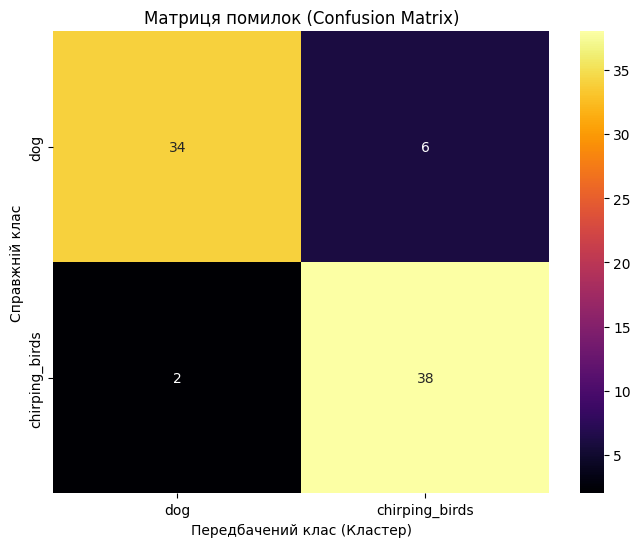

In [21]:
# 6. Аналіз отриманих кластерів
cm = confusion_matrix(y_true, y_pred)
print("\nМатриця помилок (Confusion Matrix):")
print(cm)

# Якщо кластери "перевернуті", інвертуємо передбачення для зручності оцінки
if cm[0, 1] + cm[1, 0] > cm[0, 0] + cm[1, 1]:
    y_pred = 1 - y_pred
    cm = confusion_matrix(y_true, y_pred)

# Налаштування розміру графіка
plt.figure(figsize=(8, 6))

# Створення теплової карти
sns.heatmap(cm, annot=True, fmt='d', cmap='inferno',
            xticklabels=['dog', 'chirping_birds'],
            yticklabels=['dog', 'chirping_birds'])

plt.title('Матриця помилок (Confusion Matrix)')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас (Кластер)')
plt.show()


## 7. Висновки
Як видно з побудованих осцилограм (графіків амплітуди від часу), сирий звуковий сигнал є дуже хаотичним. Хоча візуально можна помітити різницю в щільності хвилі між гавкотом та співом, виділити з цього графіка чіткі математичні ознаки для машинного навчання вкрай важко. Саме тому перехід до спектрограми є необхідним кроком.

**Аналіз отриманих кластерів**\
Результати кластеризації демонструють, що алгоритм успішно розділив спостереження на дві відокремлені групи. Звуки різного походження (гавкіт собаки та спів птахів) потрапили в різні кластери, що підтверджується показниками точності та матрицею помилок.

Це пояснюється різною акустичним характером цих сигналів, яка чітко відображається на їхніх спектрограмах:
* **Собачий гавкіт:** На спектрограмі він виглядає як різкі, короткочасні та широкосмугові сплески (вертикальні лінії), зосереджені переважно в нижньому та середньому діапазонах частот.
* **Спів птахів:** Складається з високочастотних і тривалих тонів. На графіку вони утворюють горизонтальні або хвилясті лінії у верхній частині спектрограми.

Застосування функції `pooling` дозволило зменшити розмірність даних і відфільтрувати дрібний шум. Завдяки цьому алгоритм `SpectralClustering` зміг ефективно згрупувати схожі частотно-часові патерни.

**Аналіз матриці помилок (Confusion Matrix) та її значення**

Для детальної оцінки якості розбиття даних на групи було побудовано матрицю помилок. Цей інструмент дозволяє побачити специфіку роботи алгоритму: не лише скільки файлів розпізнано правильно, а й як саме модель помиляється.

У нашій задачі матриця має розмір 2х2 і її структура читається так:
* **Головна діагональ (зліва направо, зверху вниз):** Показує кількість істинно позитивних та істинно негативних результатів — тобто аудіофайли, які алгоритм правильно згрупував (собак відніс до кластера собак -34, а птахів до птахів -38).
* **Інші клітинки (помилки першого та другого роду):** Показують перетини, де алгоритм заплутався. Наприклад, скільки разів він сприйняв специфічний спів пташки за гавкіт собаки, або навпаки.

Високі  значення на головній діагоналі підтверджують ефективність обраного методу. Це означає, що після застосування перетворення Фур'є та зменшення розмірності за допомогою пулінгу, ознаки двох класів стали настільки математично відмінними, що алгоритм `SpectralClustering` зміг провести між ними межу.

Якби матриця показала високі значення помилок у певній клітинці, це сигналізувало б нам про те, що деякі звуки мають схожі частотно-часові патерни (наприклад, низькочастотний крик птаха міг би бути сприйнятий як гавкіт собаки). Але матриця демонструє, що в нашій вибірці такі аномалії майже відсутні.

**Висновок про значення застосування перетворення Фур'є для вилучення ознак даних:**

Застосування перетворення Фур'є важливим етапом у послідовності обробки аудіоданих. Його ключове значення полягає у наступному:

1. Перетворення Фур'є розкладає складну хвилю на базові частоти, виявляючи фізичну структуру звуку (висоту тону, тембр, ритмічність).
2. Спектрограма перетворює одновимірний часовий ряд на двовимірну матрицю (зображення, де осі — це час та частота, а значення — сила звучання).
3. Отримане двовимірне представлення дозволяє застосовувати стандартні методи аналізу матриць та машинного навчання (такі як `flatten()` для векторизації, кластеризацію). Без перетворення Фур'є алгоритм не зміг би знайти геометричні та структурні закономірності у звукових даних.